In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("/content/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.duplicated().sum()

np.int64(0)

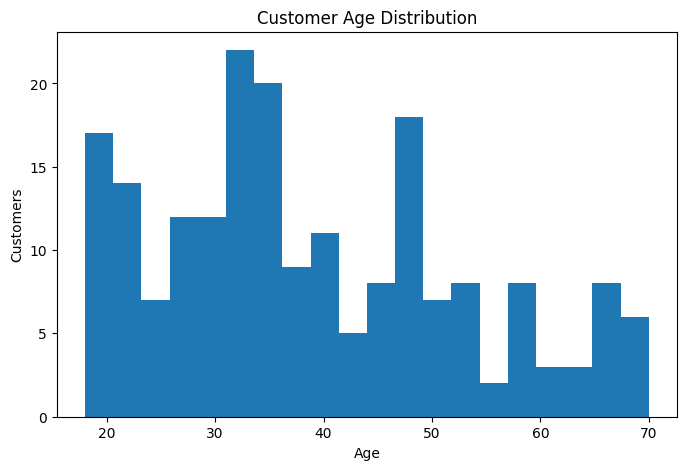

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=20)

plt.xlabel("Age")
plt.ylabel("Customers")
plt.title("Customer Age Distribution")

plt.savefig("age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

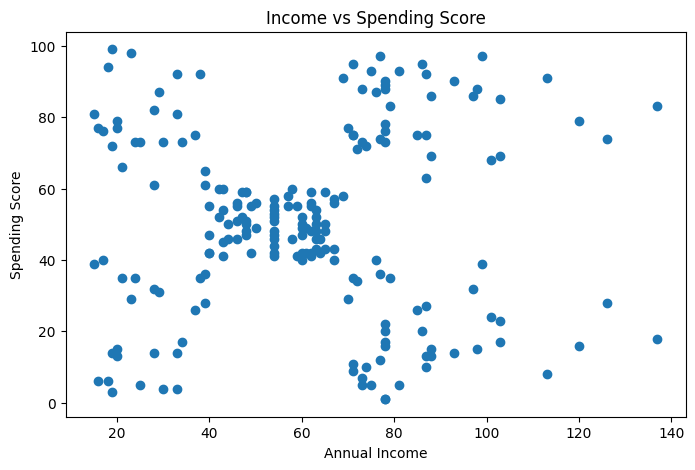

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Income vs Spending Score")

plt.savefig("income_vs_spending.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [ ]:
inertia = []
for k in range(1,11):
  kmeans = KMeans(
      n_clusters = k,
      random_state = 42
  )

  kmeans.fit(X)
  inertia.append(kmeans.inertia_)

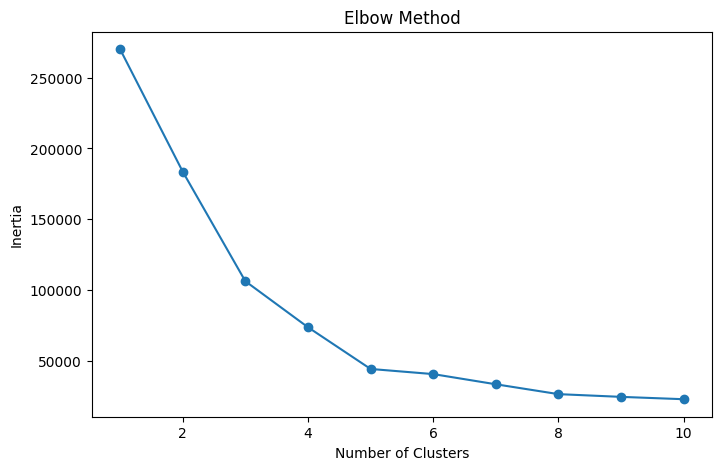

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.savefig("elbow_method.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters = 5,
    random_state = 42
)
clusters = kmeans.fit_predict(X)

df['Cluster'] = clusters

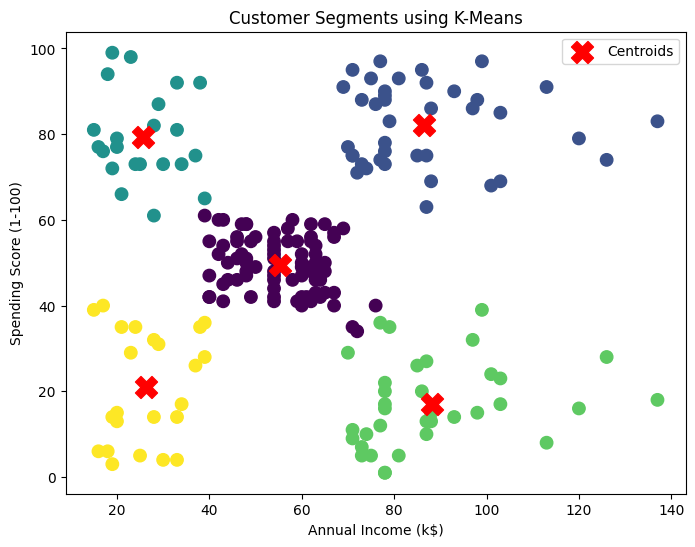

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    s=80
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=250,
    marker="X",
    color="red",
    label="Centroids"
)

plt.title("Customer Segments using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()

plt.savefig("customer_clusters.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
df.groupby("Cluster").mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


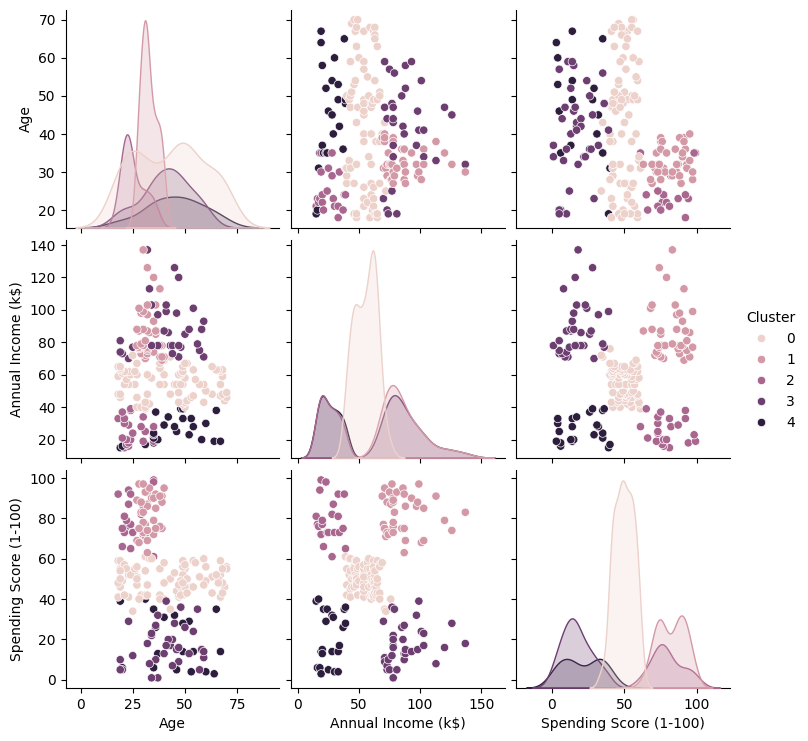

In [ ]:
import seaborn as sns

sns.pairplot(
    df,
    vars=["Age", "Annual Income (k$)", "Spending Score (1-100)"],
    hue="Cluster"
)

plt.savefig("pairplot_clusters.png", dpi=300, bbox_inches="tight")
plt.show()